Forma antes de recorte: (129, 129, 64)
Forma tras recorte: (128, 128, 64)


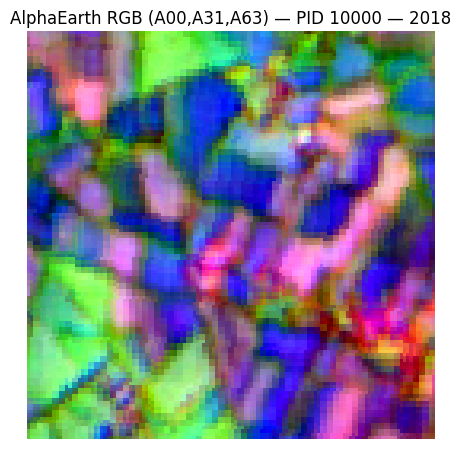

In [ ]:
# === UNA PARCELA: AlphaEarth RGB sintético 128x128 (sin máscara, usando CSV local) ===
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import ee
ee.Initialize(project='fonseca-472504')

# ---------------- Config ----------------
CSV_PATH   = './pastis_parcel_coords_all.csv'   # CSV local junto al notebook
PID        = '10000'                            # <- id de parcela a probar (cadena)
YEAR       = 2018
PATCH_PX   = 128
SCALE_M    = 10                                  # 10 m (AlphaEarth anual)
FILL_VALUE = -9999.0
BANDS      = [f'A{i:02d}' for i in range(64)]

# ---------- Utilidades ----------
def rgb_from_bands(X, picks=(0,31,63)):
    """RGB [H,W,3] con bandas elegidas y estirado 2-98% (ignora NaNs)."""
    rgb = np.zeros((X.shape[0], X.shape[1], 3), dtype=np.float32)
    for i,b in enumerate(picks):
        v = X[..., b]
        vv = v[~np.isnan(v)]
        if vv.size == 0:
            continue
        p2, p98 = np.percentile(vv, [2, 98])
        vv = (v - p2) / max(p98 - p2, 1e-6)
        rgb[..., i] = np.clip(vv, 0, 1)
    return rgb

# -------- 1) CSV -> lon/lat de la parcela --------
df = pd.read_csv(CSV_PATH)
assert {'parcel_id','lon','lat'}.issubset(df.columns), "CSV debe tener columnas: parcel_id, lon, lat"
row = df.loc[df['parcel_id'].astype(str) == str(PID)]
if row.empty:
    raise RuntimeError(f"PID {PID} no existe en {CSV_PATH}")
lon = float(row['lon'].values[0]); lat = float(row['lat'].values[0])

# -------- 2) AlphaEarth anual (mosaico, 64 bandas escalares) --------
start = ee.Date.fromYMD(YEAR,1,1); end = start.advance(1,'year')
ae = (ee.ImageCollection('GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL')
        .filterDate(start, end)
        .filterBounds(ee.Geometry.Point([lon,lat], 'EPSG:4326').buffer(500))
        .mosaic()
        .select(BANDS)
        .unmask(FILL_VALUE)
        .reproject('EPSG:2154', None, SCALE_M)              # fuerza L93 @ 10 m
        .setDefaultProjection('EPSG:2154', None, SCALE_M))

# -------- 3) Vecindario ~129x129 por banda usando neighborhoodToArray (sobre bandas escalares) --------
kernel = ee.Kernel.square(PATCH_PX//2, 'pixels', True)     # radio=64 px → ~129x129 (luego recorte a 128)
nb = ae.neighborhoodToArray(kernel)                        # <-- entrada ESCALAR, salida: cada banda es array 2D

# Punto central en la proyección del mosaico
proj = nb.projection()
pt   = ee.Geometry.Point([lon, lat], 'EPSG:4326').transform(proj, 1)

# Extrae el 'primer' valor del píxel central (cada banda ahora es una matriz NxN)
d = nb.reduceRegion(
        reducer   = ee.Reducer.first(),
        geometry  = pt,
        scale     = SCALE_M,
        maxPixels = 1e9,
        tileScale = 2
    )

# ---- 4) Dict -> tensor [H,W,64] ----
mats = []
H_est = PATCH_PX + 1  # valor esperado ~129
W_est = PATCH_PX + 1
for b in BANDS:
    valb = d.get(b)
    if valb is None:
        arr2d = np.full((H_est, W_est), np.nan, dtype=np.float32)
    else:
        arr2d = np.array(ee.Array(valb).getInfo(), dtype=np.float32)
    mats.append(arr2d[..., None])  # [H,W,1]

X = np.concatenate(mats, axis=-1)  # [H,W,64]

# Sustituye el relleno por NaN si hubiera sobrevivido
X[X == FILL_VALUE] = np.nan

print("Forma antes de recorte:", X.shape)  # normalmente (129,129,64)

# ---- 5) Recorte centrado a 128x128 (con pad si hiciera falta) ----
H, W = X.shape[:2]
cy, cx = H//2, W//2
half = PATCH_PX//2
y0, y1 = max(0, cy-half), min(H, cy+half)
x0, x1 = max(0, cx-half), min(W, cx+half)
A = X[y0:y1, x0:x1, :]
if A.shape[0] != PATCH_PX or A.shape[1] != PATCH_PX:
    A2 = np.full((PATCH_PX, PATCH_PX, 64), np.nan, dtype=np.float32)
    A2[:A.shape[0], :A.shape[1], :] = A
    A = A2

print("Forma tras recorte:", A.shape)  # (128,128,64)

# -------- 6) Visualiza RGB sintético (A00, A31, A63) --------
rgb = rgb_from_bands(A, picks=(0,31,63))
plt.figure(figsize=(4.6,4.6))
plt.imshow(rgb)
plt.title(f'AlphaEarth RGB (A00,A31,A63) — PID {PID} — {YEAR}')
plt.axis('off'); plt.tight_layout(); plt.show()


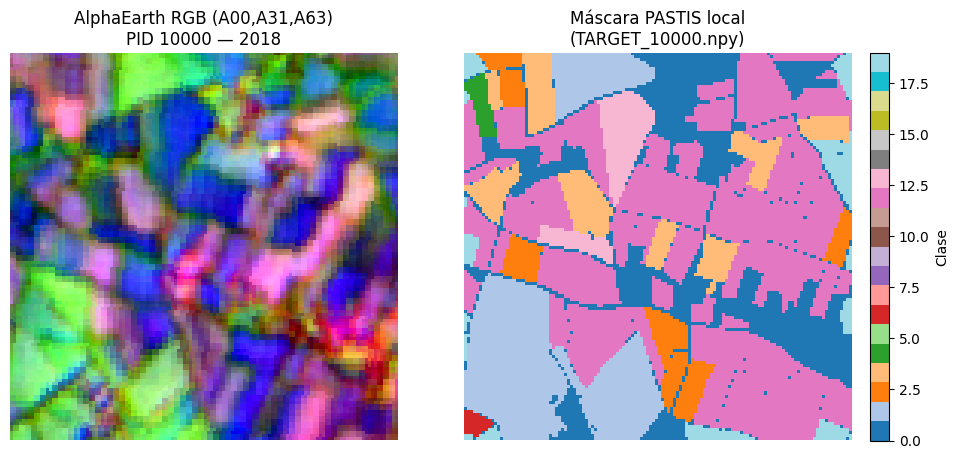

AE patch: (128, 128, 64) | mask: (128, 128)


In [16]:
# === AlphaEarth 128x128 + Máscara PASTIS local (lado a lado) ===
import os, glob, re
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import ee

ee.Initialize(project='fonseca-472504')

# ---------------- Config ----------------
CSV_PATH        = './pastis_parcel_coords_all.csv'      # CSV junto al notebook
PID             = '10000'                               # parcela a probar
YEAR            = 2018
PATCH_PX        = 128
SCALE_M         = 10                                    # 10 m (AE anual)
FILL_VALUE      = -9999.0
BANDS           = [f'A{i:02d}' for i in range(64)]

# Si ya generaste máscaras 128x128 con tu batch:
OUT_DIR         = f'./data/ALPHAEARTH/{YEAR}'
# Si NO existe la máscara 128 en OUT_DIR, tomamos la original PASTIS:
PASTIS_ANN_ROOT = '../PASTIS/PASTIS/ANNOTATIONS'        # <-- ajusta a tu ruta local

# ---------- Utils ----------
def rgb_from_bands(X, picks=(0,31,63)):
    rgb = np.zeros((X.shape[0], X.shape[1], 3), dtype=np.float32)
    for i,b in enumerate(picks):
        v = X[..., b]
        vv = v[~np.isnan(v)]
        if vv.size == 0:
            continue
        p2, p98 = np.percentile(vv, [2, 98])
        vv = (v - p2) / max(p98 - p2, 1e-6)
        rgb[..., i] = np.clip(vv, 0, 1)
    return rgb

def center_crop_or_pad(img, target_h, target_w, fill):
    H, W = img.shape[:2]
    y0 = max((H - target_h)//2, 0); x0 = max((W - target_w)//2, 0)
    y1 = y0 + min(target_h, H);     x1 = x0 + min(target_w, W)
    cropped = img[y0:y1, x0:x1, ...]
    ph = target_h - cropped.shape[0]; pw = target_w - cropped.shape[1]
    if ph > 0 or pw > 0:
        out = np.full([target_h, target_w] + list(img.shape[2:]), fill, dtype=img.dtype)
        oy = (target_h - cropped.shape[0])//2; ox = (target_w - cropped.shape[1])//2
        out[oy:oy+cropped.shape[0], ox:ox+cropped.shape[1], ...] = cropped
        return out
    return cropped

def load_mask_local(pid):
    """1) intenta OUT_DIR/MASK_{pid}_128.npy; 2) si no, PASTIS TARGET_{pid}.npy y ajusta a 128x128."""
    # opción 1: ya preprocesada a 128
    pre = os.path.join(OUT_DIR, f"MASK_{pid}_128.npy")
    if os.path.isfile(pre):
        m = np.load(pre).astype(np.float32)  # puede venir int16; pasamos a float p/ NaN si se necesita
        return m, pre, True  # True = ya 128x128

    # opción 2: máscara PASTIS cruda TARGET_{pid}.npy
    cand = [
        os.path.join(PASTIS_ANN_ROOT, f"TARGET_{pid}.npy"),
        os.path.join(PASTIS_ANN_ROOT, f"TARGET_{int(pid)}.npy") if str(pid).isdigit() else ""
    ]
    fp = next((p for p in cand if p and os.path.isfile(p)), None)
    if fp is None:
        # búsqueda laxa
        pats = glob.glob(os.path.join(PASTIS_ANN_ROOT, "TARGET_*.npy"))
        r = re.compile(rf"TARGET_{re.escape(str(pid))}\.npy$")
        for p in pats:
            if r.search(os.path.basename(p)):
                fp = p; break
    if fp is None:
        raise FileNotFoundError(f"No encontré máscara local para PID={pid}")

    arr = np.load(fp)
    # distintos formatos posibles
    if arr.ndim == 2:
        m = arr
    elif arr.ndim == 3 and arr.shape[0] in (1,3):
        m = arr[0]
    elif arr.ndim == 3 and arr.shape[-1] in (1,3):
        m = np.moveaxis(arr, -1, 0)[0]
    else:
        raise ValueError(f"Formato inesperado en {fp}: {arr.shape}")
    m = m.astype(np.float32)
    m[m == -1] = np.nan  # -1 como nodata
    # centra a 128x128
    m128 = center_crop_or_pad(m[...,None], PATCH_PX, PATCH_PX, fill=np.nan).squeeze()
    return m128, fp, False

# -------- 1) CSV -> lon/lat de la parcela --------
df = pd.read_csv(CSV_PATH)
assert {'parcel_id','lon','lat'}.issubset(df.columns), "CSV debe tener columnas: parcel_id, lon, lat"
row = df.loc[df['parcel_id'].astype(str) == str(PID)]
if row.empty:
    raise RuntimeError(f"PID {PID} no existe en {CSV_PATH}")
lon = float(row['lon'].values[0]); lat = float(row['lat'].values[0])

# -------- 2) AE anual (64 bandas escalares), L93 @ 10m --------
start = ee.Date.fromYMD(YEAR,1,1); end = start.advance(1,'year')
ae = (ee.ImageCollection('GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL')
        .filterDate(start, end)
        .filterBounds(ee.Geometry.Point([lon,lat], 'EPSG:4326').buffer(500))
        .mosaic()
        .select(BANDS)
        .unmask(FILL_VALUE)
        .reproject('EPSG:2154', None, SCALE_M)     # fuerza L93
        .setDefaultProjection('EPSG:2154', None, SCALE_M))

# -------- 3) Vecindario ~129x129 con neighborhoodToArray (evita límite de píxeles) --------
kernel = ee.Kernel.square(PATCH_PX//2, 'pixels', True)  # radio=64 → ~129x129
nb = ae.neighborhoodToArray(kernel)

# Punto central en proyección del mosaico
proj = nb.projection()
pt   = ee.Geometry.Point([lon, lat], 'EPSG:4326').transform(proj, 1)

# Extrae en el píxel central
d = nb.reduceRegion(
        reducer   = ee.Reducer.first(),
        geometry  = pt,
        scale     = SCALE_M,
        maxPixels = 1e9,
        tileScale = 2
    )

# Dict → tensor [H,W,64]
mats = []
H_est = PATCH_PX + 1  # ~129
W_est = PATCH_PX + 1
for b in BANDS:
    valb = d.get(b)
    if valb is None:
        arr2d = np.full((H_est, W_est), np.nan, dtype=np.float32)
    else:
        arr2d = np.array(ee.Array(valb).getInfo(), dtype=np.float32)
    mats.append(arr2d[..., None])
X = np.concatenate(mats, axis=-1)  # [~129, ~129, 64]
X[X == FILL_VALUE] = np.nan

# Recorta centrado a 128x128
H, W = X.shape[:2]
cy, cx = H//2, W//2
half = PATCH_PX//2
A = X[cy-half:cy+half, cx-half:cx+half, :]
if A.shape[:2] != (PATCH_PX, PATCH_PX):
    A = center_crop_or_pad(A, PATCH_PX, PATCH_PX, fill=np.nan)

# -------- 4) Carga máscara local --------
M, mpath, was128 = load_mask_local(PID)

# -------- 5) Visualización lado a lado --------
rgb = rgb_from_bands(A, picks=(0,31,63))

fig, ax = plt.subplots(1, 2, figsize=(10, 4.6))
ax[0].imshow(rgb)
ax[0].set_title(f'AlphaEarth RGB (A00,A31,A63)\nPID {PID} — {YEAR}')
ax[0].axis('off')

im = ax[1].imshow(M, interpolation='nearest', cmap='tab20')
ax[1].set_title(f'Máscara PASTIS local\n({os.path.basename(mpath)}){" [128]" if was128 else ""}')
ax[1].axis('off')
cbar = plt.colorbar(im, ax=ax[1], fraction=0.046, pad=0.04)
cbar.set_label('Clase')

plt.tight_layout()
plt.show()

print("AE patch:", A.shape, "| mask:", M.shape)


In [17]:
# === Guardar AE 128x128x64 para TODAS las parcelas (CSV) y validar con 1 muestra RGB vs máscara PASTIS ===
import os, re, glob, random
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from tqdm import tqdm
import ee

# ---------- Init EE ----------
ee.Initialize(project='fonseca-472504')

# ---------- Config ----------
CSV_PATH        = './pastis_parcel_coords_all.csv'   # CSV local con columnas: parcel_id, lon, lat
YEAR            = 2018
PATCH_PX        = 128
SCALE_M         = 10
FILL_VALUE      = -9999.0
BANDS           = [f'A{i:02d}' for i in range(64)]

# Carpeta donde guardaremos los tensores (solo AE)
OUT_DIR         = f'./data/ALPHAEARTH/{YEAR}'
os.makedirs(OUT_DIR, exist_ok=True)

# Carpeta donde están las máscaras PASTIS locales (para la validación final)
PASTIS_ANN_ROOT = '../PASTIS/PASTIS/ANNOTATIONS'      # <-- ajusta

# ---------- Utils ----------
def center_crop_or_pad(img, target_h, target_w, fill):
    H, W = img.shape[:2]
    y0 = max((H - target_h)//2, 0); x0 = max((W - target_w)//2, 0)
    y1 = y0 + min(target_h, H);     x1 = x0 + min(target_w, W)
    cropped = img[y0:y1, x0:x1, ...]
    ph = target_h - cropped.shape[0]; pw = target_w - cropped.shape[1]
    if ph > 0 or pw > 0:
        out = np.full([target_h, target_w] + list(img.shape[2:]), fill, dtype=img.dtype)
        oy = (target_h - cropped.shape[0])//2; ox = (target_w - cropped.shape[1])//2
        out[oy:oy+cropped.shape[0], ox:ox+cropped.shape[1], ...] = cropped
        return out
    return cropped

def rgb_from_bands(X, picks=(0,31,63)):
    """Genera un RGB [H,W,3] con estirado 2-98% ignorando NaNs."""
    rgb = np.zeros((X.shape[0], X.shape[1], 3), dtype=np.float32)
    for i,b in enumerate(picks):
        v = X[..., b]
        vv = v[~np.isnan(v)]
        if vv.size == 0:
            continue
        p2, p98 = np.percentile(vv, [2, 98])
        vv = (v - p2) / max(p98 - p2, 1e-6)
        rgb[..., i] = np.clip(vv, 0, 1)
    return rgb

def load_mask_local(pid):
    """Carga máscara PASTIS local para un PID y la centra a 128x128 para visualizar."""
    # candidatos comunes
    candidates = [
        os.path.join(PASTIS_ANN_ROOT, f"TARGET_{pid}.npy"),
        os.path.join(PASTIS_ANN_ROOT, f"TARGET_{int(pid)}.npy") if str(pid).isdigit() else ""
    ]
    fp = next((p for p in candidates if p and os.path.isfile(p)), None)
    if fp is None:
        # búsqueda laxa
        patt = re.compile(rf"TARGET_{re.escape(str(pid))}\.npy$")
        for p in glob.glob(os.path.join(PASTIS_ANN_ROOT, "TARGET_*.npy")):
            if patt.search(os.path.basename(p)):
                fp = p; break
    if fp is None:
        return None, None

    arr = np.load(fp)
    if arr.ndim == 2:
        m = arr
    elif arr.ndim == 3 and arr.shape[0] in (1,3):
        m = arr[0]
    elif arr.ndim == 3 and arr.shape[-1] in (1,3):
        m = np.moveaxis(arr, -1, 0)[0]
    else:
        return None, None
    m = m.astype(np.float32)
    m[m == -1] = np.nan
    m128 = center_crop_or_pad(m[...,None], PATCH_PX, PATCH_PX, fill=np.nan).squeeze()
    return m128, fp

def fetch_ae_patch_128(lon, lat, year):
    """Devuelve tensor 128x128x64 de AlphaEarth centrado en (lon,lat) usando neighborhoodToArray."""
    start = ee.Date.fromYMD(year,1,1); end = start.advance(1,'year')
    # 64 bandas escalares
    ae = (ee.ImageCollection('GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL')
            .filterDate(start, end)
            .filterBounds(ee.Geometry.Point([lon,lat], 'EPSG:4326').buffer(500))
            .mosaic()
            .select(BANDS)
            .unmask(FILL_VALUE)
            .reproject('EPSG:2154', None, SCALE_M)
            .setDefaultProjection('EPSG:2154', None, SCALE_M))

    # Vecindario ~129x129 (radio=64 px). neighborhoodToArray funciona con bandas escalares.
    kernel = ee.Kernel.square(PATCH_PX//2, 'pixels', True)
    nb = ae.neighborhoodToArray(kernel)

    proj = nb.projection()
    pt = ee.Geometry.Point([lon, lat], 'EPSG:4326').transform(proj, 1)

    d = nb.reduceRegion(
            reducer   = ee.Reducer.first(),
            geometry  = pt,
            scale     = SCALE_M,
            maxPixels = 1e9,
            tileScale = 2
        )

    # Construir tensor [~129,~129,64]
    mats = []
    H_est = PATCH_PX + 1
    W_est = PATCH_PX + 1
    for b in BANDS:
        valb = d.get(b)
        if valb is None:
            arr2d = np.full((H_est, W_est), np.nan, dtype=np.float32)
        else:
            arr2d = np.array(ee.Array(valb).getInfo(), dtype=np.float32)
        mats.append(arr2d[..., None])
    X = np.concatenate(mats, axis=-1)
    X[X == FILL_VALUE] = np.nan

    # recorte/pad centrado a 128
    H, W = X.shape[:2]
    cy, cx = H//2, W//2
    half = PATCH_PX//2
    A = X[cy-half:cy+half, cx-half:cx+half, :]
    if A.shape[:2] != (PATCH_PX, PATCH_PX):
        A = center_crop_or_pad(A, PATCH_PX, PATCH_PX, fill=np.nan)
    return A.astype(np.float32)

# ---------- 1) Leer CSV ----------
df = pd.read_csv(CSV_PATH)
assert {'parcel_id','lon','lat'}.issubset(df.columns), "CSV debe tener columnas: parcel_id, lon, lat"

# ---------- 2) Loop: guardar todos los tensores ----------
saved, skipped = [], []
for _, r in tqdm(df.iterrows(), total=len(df), desc="Guardando AE 128x128x64"):
    pid = str(r['parcel_id'].astype('int'))
    lon = float(r['lon']); lat = float(r['lat'])
    out_path = os.path.join(OUT_DIR, f"ALPHA_{pid}.npy")
    if os.path.isfile(out_path):
        saved.append(pid)  # ya existía, lo contamos igual
        continue
    try:
        A = fetch_ae_patch_128(lon, lat, YEAR)
        # si todo es NaN, omitimos
        if np.isnan(A).all():
            skipped.append((pid, "todo NaN (fuera de cobertura)"))
            continue
        np.save(out_path, A, allow_pickle=False)
        saved.append(pid)
    except Exception as e:
        skipped.append((pid, str(e)))

print(f"\n✅ Guardados: {len(saved)} en {os.path.abspath(OUT_DIR)}")
if skipped:
    print(f"⚠️ Omitidos: {len(skipped)}")
    for pid, msg in skipped[:10]:
        print(f"  - {pid}: {msg}")

# ---------- 3) Validación: elegir 1 PID al azar que tenga máscara local ----------
candidates = []
for pid in saved:
    # ¿existe máscara local para este pid?
    m, fp = load_mask_local(pid)
    if m is not None:
        candidates.append(pid)

if not candidates:
    print("\n⚠️ No encontré ninguna parcela guardada con máscara PASTIS local disponible para validar.")
else:
    pid_v = random.choice(candidates)
    # carga tensor AE y máscara
    A = np.load(os.path.join(OUT_DIR, f"ALPHA_{pid_v}_128.npy"))
    M, mpath = load_mask_local(pid_v)
    rgb = rgb_from_bands(A, picks=(0,31,63))

    fig, ax = plt.subplots(1, 2, figsize=(10, 4.6))
    ax[0].imshow(rgb)
    ax[0].set_title(f'AlphaEarth RGB (A00,A31,A63)\nPID {pid_v} — {YEAR}')
    ax[0].axis('off')

    im = ax[1].imshow(M, interpolation='nearest', cmap='tab20')
    ax[1].set_title(f'Máscara PASTIS local\n{os.path.basename(mpath)}')
    ax[1].axis('off')
    cbar = plt.colorbar(im, ax=ax[1], fraction=0.046, pad=0.04)
    cbar.set_label('Clase')

    plt.tight_layout()
    plt.show()


Guardando AE 128x128x64: 100%|██████████| 2433/2433 [9:23:56<00:00, 13.91s/it]  



✅ Guardados: 2433 en c:\Users\LuisA\OneDrive\Documents\Proyect Final Cultivos MNA\MNA_Proyectos_Cultivos\data\ALPHAEARTH\2018


FileNotFoundError: [Errno 2] No such file or directory: './data/ALPHAEARTH/2018\\ALPHA_20092_128.npy'

Guardando EUCROPMAP 128x128: 100%|██████████| 2433/2433 [07:08<00:00,  5.67it/s]



✅ Guardadas: 2433 en c:\Users\LuisA\OneDrive\Documents\Proyect Final Cultivos MNA\MNA_Proyectos_Cultivos\data\EUROCROP_MASK\2018


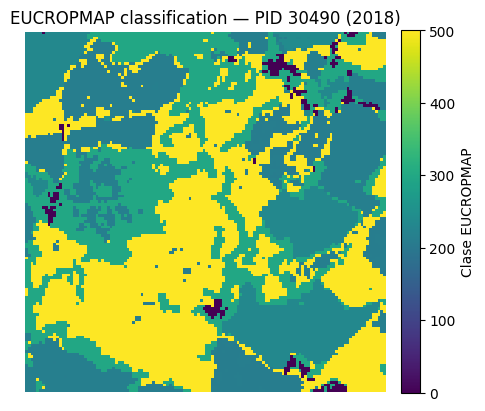

In [2]:
# === Descargar máscara EUCROPMAP 128x128 para las mismas parcelas ===
import os, re, glob, random
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from tqdm import tqdm
import ee

# ---------- Init EE ----------
ee.Initialize(project='fonseca-472504')

# ---------- Config ----------
CSV_PATH        = './pastis_parcel_coords_all.csv'   # columnas: parcel_id, lon, lat
YEAR            = 2018                               # EUCROPMAP: 2018 o 2022
PATCH_PX        = 128
SCALE_M         = 10
MASK_FILL       = -1                                 # nodata fuera de cobertura
EE_EUCROP_ID    = 'JRC/D5/EUCROPMAP/V1'

# Carpeta de salida (similar a embeddings)
OUT_DIR_MASK    = f'./data/EUROCROP_MASK/{YEAR}'
os.makedirs(OUT_DIR_MASK, exist_ok=True)

# (opcional) dónde están tus AlphaEarth, para validar una muestra con RGB
ALPHA_DIR       = f'./data/ALPHAEARTH/{YEAR}'

# ---------- Utils (mismas que ya usas) ----------
def center_crop_or_pad(img, target_h, target_w, fill):
    H, W = img.shape[:2]
    y0 = max((H - target_h)//2, 0); x0 = max((W - target_w)//2, 0)
    y1 = y0 + min(target_h, H);     x1 = x0 + min(target_w, W)
    cropped = img[y0:y1, x0:x1, ...]
    ph = target_h - cropped.shape[0]; pw = target_w - cropped.shape[1]
    if ph > 0 or pw > 0:
        out = np.full([target_h, target_w] + list(img.shape[2:]), fill, dtype=img.dtype)
        oy = (target_h - cropped.shape[0])//2; ox = (target_w - cropped.shape[1])//2
        out[oy:oy+cropped.shape[0], ox:ox+cropped.shape[1], ...] = cropped
        return out
    return cropped

def fetch_eucrop_mask_128(lon, lat, year):
    """Devuelve máscara EUCROPMAP 128x128 (int16) centrada en (lon,lat)."""
    if year not in (2018, 2022):
        raise ValueError("EUCROPMAP solo está disponible para YEAR=2018 o 2022.")
    start = ee.Date.fromYMD(year, 1, 1); end = start.advance(1, 'year')

    # Imagen de ese año, banda 'classification'; reproject para alinear con AlphaEarth (10 m, EPSG:2154)
    img = (ee.ImageCollection(EE_EUCROP_ID)
           .filterDate(start, end).first())
    if img is None:
        raise RuntimeError(f"No hay imagen EUCROPMAP para {year}.")

    cls = (img.select('classification')
              .unmask(MASK_FILL)
              .reproject('EPSG:2154', None, SCALE_M)
              .setDefaultProjection('EPSG:2154', None, SCALE_M))

    # Vecindario ~129x129 (radio=64 px) y extracción centrada
    kernel = ee.Kernel.square(PATCH_PX//2, 'pixels', True)
    nb = cls.neighborhoodToArray(kernel)

    proj = nb.projection()
    pt = ee.Geometry.Point([lon, lat], 'EPSG:4326').transform(proj, 1)

    d = nb.reduceRegion(
        reducer   = ee.Reducer.first(),
        geometry  = pt,
        scale     = SCALE_M,
        maxPixels = 1e9,
        tileScale = 2
    )

    val = d.get('classification')
    H_est = PATCH_PX + 1
    W_est = PATCH_PX + 1
    if val is None:
        arr = np.full((H_est, W_est), MASK_FILL, dtype=np.int16)
    else:
        arr = np.array(ee.Array(val).getInfo(), dtype=np.int16)

    # Recorte centrado 128x128 (y pad si hiciera falta)
    H, W = arr.shape
    cy, cx = H//2, W//2; half = PATCH_PX//2
    A = arr[cy-half:cy+half, cx-half:cx+half]
    if A.shape != (PATCH_PX, PATCH_PX):
        A = center_crop_or_pad(A[...,None], PATCH_PX, PATCH_PX, fill=MASK_FILL).squeeze()
    return A

# ---------- 1) Leer CSV ----------
df = pd.read_csv(CSV_PATH)
assert {'parcel_id','lon','lat'}.issubset(df.columns), "CSV debe tener columnas: parcel_id, lon, lat"

# ---------- 2) Loop: guardar todas las máscaras ----------
saved, skipped = [], []
for _, r in tqdm(df.iterrows(), total=len(df), desc="Guardando EUCROPMAP 128x128"):
    pid = str(int(r['parcel_id']))
    lon = float(r['lon']); lat = float(r['lat'])
    out_path = os.path.join(OUT_DIR_MASK, f"MASK_{pid}.npy")
    if os.path.isfile(out_path):
        saved.append(pid)
        continue
    try:
        M = fetch_eucrop_mask_128(lon, lat, YEAR)
        if np.all(M == MASK_FILL):
            skipped.append((pid, "todo nodata (-1) — fuera de cobertura EUCROPMAP"))
            continue
        np.save(out_path, M.astype(np.int16), allow_pickle=False)
        saved.append(pid)
    except Exception as e:
        skipped.append((pid, str(e)))

print(f"\n✅ Guardadas: {len(saved)} en {os.path.abspath(OUT_DIR_MASK)}")
if skipped:
    print(f"⚠️ Omitidas: {len(skipped)} (primeras 10):")
    for pid, msg in skipped[:10]:
        print(f"  - {pid}: {msg}")

# ---------- 3) (Opcional) Validación rápida: muestra una máscara al azar ----------
try:
    if saved:
        pid_v = random.choice(saved)
        M = np.load(os.path.join(OUT_DIR_MASK, f"MASK_{pid_v}.npy"))
        fig, ax = plt.subplots(1, 1, figsize=(4.8, 4.8))
        im = ax.imshow(M, interpolation='nearest')
        ax.set_title(f'EUCROPMAP classification — PID {pid_v} ({YEAR})')
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Clase EUCROPMAP')
        plt.tight_layout(); plt.show()
except Exception as e:
    print("Validación omitida:", e)


Alpha path: ./data/ALPHAEARTH/2018\ALPHA_10000.npy
Mask  path: ./data/EUROCROP_MASK/2018\MASK_10000.npy
Shapes -> Alpha: (128, 128, 64) | Mask: (128, 128)
Clases (top 10 por píxeles):
   216 — Maíz: 4794
   500 — Pastizales: 3345
   290 — Tierra arable sin cultivar: 2328
   211 — Trigo común: 1423
   213 — Barley: 1036
   300 — Bosques y arbustos (incl. cultivos permanentes): 936
   240 — Legumbres secas: 648
   221 — Papas: 400
   231 — Girasol: 186
   223 — Otras raíces: 20
Fracción NaN (nodata) en máscara: 0.076


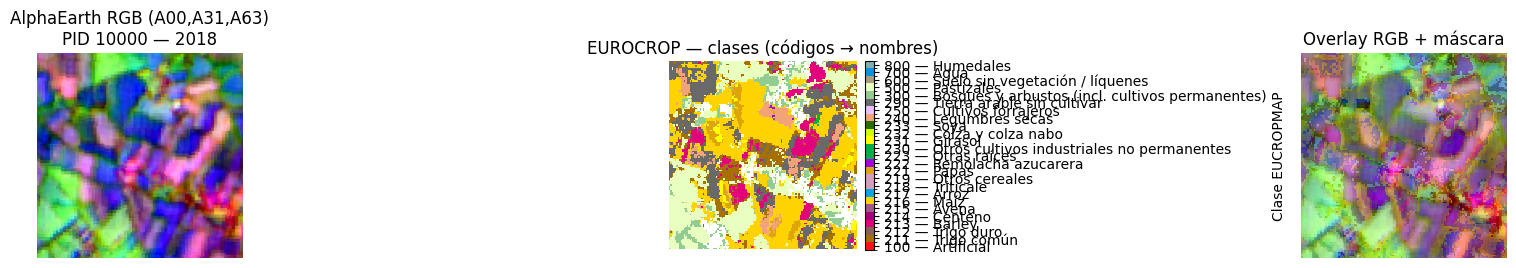

In [4]:
# === Verificación local con nombres/colores EUCROPMAP ===
import os, numpy as np, matplotlib.pyplot as plt
from matplotlib import colors as mcolors

# ---------------- Config ----------------
PID      = '10000'          # ID de parcela a probar
YEAR     = 2018
PATCH_PX = 128

# Directorios candidatos (soporta el posible typo "APLPHAEARTH")
ALPHA_DIRS    = [f'./data/ALPHAEARTH/{YEAR}', f'./data/APLPHAEARTH/{YEAR}']
EUROCROP_DIR  = f'./data/EUROCROP_MASK/{YEAR}'

# ---------------- Definición de clases (código, color_hex, nombre) ----------------
CLASSES = [
    (100, "#ff130f", "Artificial"),
    (211, "#a57000", "Trigo común"),
    (212, "#896054", "Trigo duro"),
    (213, "#e2007c", "Barley"),
    (214, "#aa007c", "Centeno"),
    (215, "#a05989", "Avena"),
    (216, "#ffd300", "Maíz"),
    (217, "#00a8e2", "Arroz"),
    (218, "#d69ebc", "Triticale"),
    (219, "#d69ebc", "Otros cereales"),
    (221, "#dda50a", "Papas"),
    (222, "#a800e2", "Remolacha azucarera"),
    (223, "#00af49", "Otras raíces"),
    (230, "#00af49", "Otros cultivos industriales no permanentes"),
    (231, "#ffff00", "Girasol"),
    (232, "#d1ff00", "Colza y colza nabo"),
    (233, "#267000", "Soya"),
    (240, "#f2a377", "Legumbres secas"),
    (250, "#e8bfff", "Cultivos forrajeros"),
    (290, "#696969", "Tierra arable sin cultivar"),
    (300, "#93cc93", "Bosques y arbustos (incl. cultivos permanentes)"),
    (500, "#e8ffbf", "Pastizales"),
    (600, "#a89e7f", "Suelo sin vegetación / líquenes"),
    (700, "#0793de", "Agua"),
    (800, "#7cafaf", "Humedales"),
]

# ---------------- Utils ----------------
def find_first_existing(paths):
    for p in paths:
        if os.path.isfile(p):
            return p
    return None

def center_crop_or_pad(img, target_h, target_w, fill):
    H, W = img.shape[:2]
    y0 = max((H - target_h)//2, 0); x0 = max((W - target_w)//2, 0)
    y1 = y0 + min(target_h, H);     x1 = x0 + min(target_w, W)
    cropped = img[y0:y1, x0:x1, ...]
    ph = target_h - cropped.shape[0]; pw = target_w - cropped.shape[1]
    if ph > 0 or pw > 0:
        out = np.full([target_h, target_w] + list(img.shape[2:]), fill, dtype=img.dtype)
        oy = (target_h - cropped.shape[0])//2; ox = (target_w - cropped.shape[1])//2
        out[oy:oy+cropped.shape[0], ox:ox+cropped.shape[1], ...] = cropped
        return out
    return cropped

def rgb_from_bands(X, picks=(0,31,63)):
    """Estirado 2-98% por canal y clip a [0,1]."""
    rgb = np.zeros((X.shape[0], X.shape[1], 3), dtype=np.float32)
    for i,b in enumerate(picks):
        v = X[..., b]
        vv = v[~np.isnan(v)]
        if vv.size == 0:
            continue
        p2, p98 = np.percentile(vv, [2, 98])
        vv = (v - p2) / max(p98 - p2, 1e-6)
        rgb[..., i] = np.clip(vv, 0, 1)
    return rgb

def load_alpha_local(pid):
    # Busca ALPHA_<pid>.npy o ALPHA_<pid>_128.npy en las carpetas candidatas
    cand = []
    for base in ALPHA_DIRS:
        cand += [os.path.join(base, f'ALPHA_{pid}.npy'),
                 os.path.join(base, f'ALPHA_{pid}_128.npy')]
    fp = find_first_existing(cand)
    if fp is None:
        raise FileNotFoundError(f"No encontré ALPHA para PID={pid} en {ALPHA_DIRS}")
    A = np.load(fp)
    if A.ndim != 3 or A.shape[-1] != 64:
        raise ValueError(f"AlphaEarth esperado [H,W,64], got {A.shape} en {fp}")
    A = center_crop_or_pad(A, PATCH_PX, PATCH_PX, fill=np.nan)
    return A.astype(np.float32), fp

def load_eurocrop_mask_local(pid):
    # Busca MASK_<pid>_128.npy (preferido) o MASK_<pid>.npy
    cand = [os.path.join(EUROCROP_DIR, f"MASK_{pid}_128.npy"),
            os.path.join(EUROCROP_DIR, f"MASK_{pid}.npy")]
    fp = find_first_existing(cand)
    if fp is None:
        raise FileNotFoundError(f"No encontré máscara EUROCROP para PID={pid} en {EUROCROP_DIR}")
    M = np.load(fp)
    if M.ndim == 3 and M.shape[-1] == 1:
        M = M[...,0]
    elif M.ndim == 3 and M.shape[0] == 1:
        M = M[0]
    elif M.ndim != 2:
        raise ValueError(f"Máscara con dims inesperadas en {fp}: {M.shape}")
    M = center_crop_or_pad(M[...,None], PATCH_PX, PATCH_PX, fill=-1).squeeze()
    M = M.astype(np.float32)
    M[M == -1] = np.nan
    return M, fp

def class_counts(arr):
    """Cuenta valores de clase (ignora NaN). Devuelve dict código->conteo."""
    vals, cnts = np.unique(arr[~np.isnan(arr)], return_counts=True)
    return dict(zip(vals.astype(int), cnts))

# ---- Mapeo a índices y colormap discreto con nombres ----
CODES  = [c for c, _, _ in CLASSES]
COLORS = [h for _, h, _ in CLASSES]
NAMES  = [n for _, _, n in CLASSES]
code_to_idx = {c:i for i, c in enumerate(CODES)}

def encode_indices_from_codes(M_float):
    """Convierte máscara con códigos reales a índices [0..K-1]; -1 para NaN/desconocido."""
    I = np.full(M_float.shape, -1, dtype=np.int16)
    if np.isnan(M_float).all():
        return I
    M_int = M_float.copy()
    M_int[np.isnan(M_int)] = -999999
    M_int = M_int.astype(np.int64)
    for code, idx in code_to_idx.items():
        I[M_int == code] = idx
    return I

# Colormap y norm: índices 0..K-1; bad (NaN) transparente
cmap = mcolors.ListedColormap(COLORS, name="eucropmap")
cmap.set_bad(alpha=0.0)
bounds = np.arange(len(COLORS) + 1) - 0.5
norm   = mcolors.BoundaryNorm(boundaries=bounds, ncolors=len(COLORS))

# ---------------- Carga ----------------
A, alpha_path = load_alpha_local(PID)
M, mask_path  = load_eurocrop_mask_local(PID)
rgb = rgb_from_bands(A, picks=(0,31,63))
I = encode_indices_from_codes(M)

print(f"Alpha path: {alpha_path}")
print(f"Mask  path: {mask_path}")
print(f"Shapes -> Alpha: {A.shape} | Mask: {M.shape}")

# Conteo rápido (por código + nombre)
cc = class_counts(M)
top = sorted(cc.items(), key=lambda x: -x[1])[:10]
pretty_top = [f"{code} — {NAMES[code_to_idx[code]]}: {cnt}" for code, cnt in top if code in code_to_idx]
print("Clases (top 10 por píxeles):")
for line in pretty_top:
    print("  ", line)
nan_frac = np.isnan(M).mean()
print(f"Fracción NaN (nodata) en máscara: {nan_frac:.3f}")

# ---------------- Visualización ----------------
fig, ax = plt.subplots(1, 3, figsize=(15, 4.8))

# 1) RGB
ax[0].imshow(rgb)
ax[0].set_title(f'AlphaEarth RGB (A00,A31,A63)\nPID {PID} — {YEAR}')
ax[0].axis('off')

# 2) Máscara con colores oficiales
im = ax[1].imshow(np.ma.masked_where(I < 0, I), cmap=cmap, norm=norm, interpolation='nearest')
ax[1].set_title('EUROCROP — clases (códigos → nombres)')
ax[1].axis('off')
cbar = plt.colorbar(im, ax=ax[1], fraction=0.046, pad=0.04, ticks=np.arange(len(CODES)))
cbar.ax.set_yticklabels([f"{c} — {n}" for c, n in zip(CODES, NAMES)])
cbar.set_label('Clase EUCROPMAP')

# 3) Overlay (RGB + máscara semi-transparente)
ax[2].imshow(rgb)
ax[2].imshow(np.ma.masked_where(I < 0, I), cmap=cmap, norm=norm, alpha=0.35, interpolation='nearest')
ax[2].set_title('Overlay RGB + máscara')
ax[2].axis('off')

plt.tight_layout()
plt.show()

